In [1]:
from matplotlib import cm

import scanpy as sc
import os
import numpy as np
import matplotlib.pyplot as plt
import re
from itertools import product
from scipy.stats import spearmanr, pearsonr
import pandas as pd
# helper function for plotting 

def remove_na_and_empty(lst):    
    return [np.array([-0.1]) if np.isnan(el).any() or el.shape == (0,) else el for el in lst]


# SEEDS = [3] #,3,4,5,6,7,8,9] changed  return gene_expression/num_paths to changed  return gene_expression in _PALAVA.py


In [2]:

ERRORS_ =   [f"MS_0_EX_0"]

ERRORS_ +=  [f"MS_{i}_EX_0" for i in [10, 20, 30, 40, 50]]

ERRORS_ +=   [f"MS_0_EX_{i}" for i in [10, 20, 30, 40, 50]]

SEEDS =[10,11,12,13,14,15,16,17,18,19]#,3,4,5,6,7,8,9]
# seed 10,11 uses 50 genes in gene sets

prefix = 'intermediate_results/'


linear_palava_results = [f'{prefix}linear_palava_results_sim_anndata_linear_model_5000_cells_2000_genes_4_factors_{seed}_seed_gene_sets_formatted_{error}.npy' for seed, error in product(SEEDS, ERRORS_)]

palava_results = [f'{prefix}palava_results_sim_anndata_linear_model_5000_cells_2000_genes_4_factors_{seed}_seed_gene_sets_formatted_{error}.npy' for seed, error in product(SEEDS, ERRORS_)]

spectra_results = [f'{prefix}spectra_results_sim_anndata_linear_model_5000_cells_2000_genes_4_factors_{seed}_seed_gene_sets_formatted_{error}.npy' for seed, error in product(SEEDS, ERRORS_)]
slalom_results = [f'{prefix}slalom_results_sim_anndata_linear_model_5000_cells_2000_genes_4_factors_{seed}_seed_gene_sets_formatted_{error}.npy' for seed, error in product(SEEDS, ERRORS_)]


In [3]:
result_directory_lst = linear_palava_results\
                        +spectra_results\
                        +palava_results\
                        +slalom_results


In [4]:
#result_directory_lst = [directory for directory in result_directory_lst if os.path.exists(directory)]


In [5]:

methods = ['palava','linear_palava', 'spectra', 'slalom'] # 'palava',
results_dict ={m:{} for m in methods}

data_directory_lst = list(set([data_directory.split('results_')[1].replace('.npy','') for data_directory in result_directory_lst]))

for method in methods:
    results_dict[method]['result_directorys'] = []
    #results_dict[method]['result_lst'] = {}

    for data_directory in  result_directory_lst:
        data_directory_method = re.search(r'intermediate_results/(.*?)_res', data_directory).group(1) if re.search(r'intermediate_results/(.*?)_res', data_directory) else None
        if  data_directory_method == method:
            
            results_dict[method]['result_directorys'] += [data_directory.split('results_')[1].replace('.npy','')]
            results_dict[method][data_directory.split('results_')[1].replace('.npy','')] = np.load(data_directory, allow_pickle=True)[()]
            # too much meme in load the slopes 
            if 'spline_slopes' in results_dict[method][data_directory.split('results_')[1].replace('.npy','')].keys():
                del results_dict[method][data_directory.split('results_')[1].replace('.npy','')]['spline_slopes']


In [6]:

# Determine num cells, genes, factors from file name
pattern = r'(\d+)'
matches = re.findall(pattern, data_directory_lst[0])
num_cells, num_genes, num_facs_ann = map(int, matches[:3])
print(f'num_cells: {num_cells}, num_genes: {num_genes}, Factors: {num_facs_ann}')


num_cells: 5000, num_genes: 2000, Factors: 4


# Use different percentile for slope summarisation in this cell

In [7]:
# for dr in results_dict['palava']['result_directorys']:
#      results_dict['palava'][dr]['factor_loadings'] = results_dict['palava'][dr]['factor_loadings_0.5q']
     

In [8]:
pattern = r'FN_(\d+)_FP_(\d+)'

# Initialize lists to store extracted values
fn_values = []
fp_values = []

# Iterate over the filenames and extract FN and FP values
for filename in result_directory_lst:
    match = re.search(pattern, filename)
    if match:
        fn_values.append(int(match.group(1)))
        fp_values.append(int(match.group(2)))
fn_values = list(set(fn_values))
fp_values = list(set(fp_values))



In [9]:
results_dict['adata']= {}
for data_directory in data_directory_lst:
    adata_data_directory = 'data/' + data_directory + '.h5ad'
    results_dict['adata'][data_directory] = sc.read(adata_data_directory)
   # print(results_dict['adata'][data_directory].uns['Ground truth gene sets'].sum(axis =0))



In [10]:


for method in methods:
    for results in results_dict[method]['result_directorys']:
            
            a_methods_factor_loadings = np.abs(results_dict[method][results]['factor_loadings'][:4,:])
            if method in ['slalom','default_slalom'] :
                        a_methods_factor_loadings = np.abs(results_dict[method][results]['posterior'][:4,:])

            gt_tols = 1-results_dict['adata'][results].uns['Ground truth gene sets'].sum(axis =0)/num_genes

            gt_tols_as_quantiles = np.diagonal(np.quantile(a_methods_factor_loadings, q = gt_tols[:, None], axis =1), axis1=1, axis2=2)

            top_per_a_methods_factor_loadings = a_methods_factor_loadings >= gt_tols_as_quantiles
        
            top_per_a_methods_factor_loadings_and_GT_gene = (results_dict['adata'][results].uns['Ground truth gene sets'].T==1) & top_per_a_methods_factor_loadings

            results_dict[method][results]['fraction_of_GT_in_top_genes'] =np.sum(top_per_a_methods_factor_loadings_and_GT_gene, axis =1)/np.sum(results_dict['adata'][results].uns['Ground truth gene sets'].T, axis =1)




for method in methods:
    for results in results_dict[method]['result_directorys']:
        
            a_methods_factor_loadings = np.abs(results_dict[method][results]['factor_loadings'][:4,:])
        
            if method in ['slalom','default_slalom'] :
                        a_methods_factor_loadings = np.abs(results_dict[method][results]['posterior'][:4,:])


            gt_tols = 1-results_dict['adata'][results].uns['Ground truth gene sets'].sum(axis =0)/num_genes

            gt_tols_as_quantiles = np.diagonal(np.quantile(a_methods_factor_loadings, q = gt_tols, axis =1).squeeze(), axis1=0, axis2=1)[:,None]

            top_per_a_methods_factor_loadings = a_methods_factor_loadings >= gt_tols_as_quantiles
            
        
            
            
            top_per_a_methods_factor_loadings_and_FN_gene = results_dict['adata'][results].uns['FN_genes'].T & top_per_a_methods_factor_loadings

            results_dict[method][results]['fraction_of_FN_recovered'] =np.sum(top_per_a_methods_factor_loadings_and_FN_gene, axis =1)/np.sum(results_dict['adata'][results].uns['FN_genes'].T, axis =1)
            results_dict[method][results]['num_of_FN_recovered'] =np.sum(top_per_a_methods_factor_loadings_and_FN_gene, axis =1)

            bottom_per_a_methods_factor_loadings = a_methods_factor_loadings >= gt_tols_as_quantiles
            bottom_per_a_methods_factor_loadings_and_FN_gene = results_dict['adata'][results].uns['FP_genes'].T & bottom_per_a_methods_factor_loadings
            results_dict[method][results]['fraction_of_FP_removed'] = np.sum(bottom_per_a_methods_factor_loadings_and_FN_gene, axis =1)/np.sum(results_dict['adata'][results].uns['Ground truth gene sets'].T, axis =1)
       
            results_dict[method][results]['num_of_FP_not_removed'] = np.sum(bottom_per_a_methods_factor_loadings_and_FN_gene, axis =1) 

/tmp/ipykernel_91077/618302842.py:41: RuntimeWarning: invalid value encountered in divide
  results_dict[method][results]['fraction_of_FN_recovered'] =np.sum(top_per_a_methods_factor_loadings_and_FN_gene, axis =1)/np.sum(results_dict['adata'][results].uns['FN_genes'].T, axis =1)


In [11]:

def pairwise_spearman_correlation(matrix1, matrix2):
    correlations = np.zeros((matrix1.shape[1], matrix2.shape[1]))
    for i in range(matrix1.shape[1]):
        for j in range(matrix2.shape[1]):
            correlation, _ = spearmanr(matrix1[:, i], matrix2[:, j])
            correlations[i, j] = correlation
    return correlations


for method in methods:
    for results in results_dict[method]['result_directorys']:
        if method in ['no_anno_palava','no_anno_linear_palava_no_bias']:
            latent = results_dict[method][results]['latent_representation']
            gt = results_dict['adata'][results].obs[['steps_1', 'steps_2', 'steps_3', 'steps_4']].values
            results_dict[method][results]['latent_respresentation_correlation_with_gt'] = np.max(np.abs(pairwise_spearman_correlation(latent,gt)), axis =0)
            continue 
        gt_latent_representation = results_dict['adata'][results].obs[['steps_1', 'steps_2', 'steps_3', 'steps_4']].values
        a_methods_latent_representation = results_dict[method][results]['latent_representation']
     
        correlations = [pearsonr(gt_latent_representation[:, i], a_methods_latent_representation[:, i]).correlation for i in range(4)]
        results_dict[method][results]['latent_respresentation_correlation_with_gt'] = np.abs(correlations)
            

In [12]:


fraction_of_FP_removed = [np.array([]) for _ in methods]
fraction_of_FN_recovered = [np.array([]) for _ in methods]
fraction_of_GT_in_top_genes = [np.array([]) for _ in methods]
latent_corr_with_gt = [np.array([]) for _ in methods]
for method_ind in range(len(methods)):
    for results in results_dict[methods[method_ind]]['result_directorys']:
            fraction_of_FP_removed[method_ind] = np.append(results_dict[methods[method_ind]][results]['fraction_of_FP_removed'], fraction_of_FP_removed[method_ind] )
            fraction_of_FN_recovered[method_ind] = np.append(results_dict[methods[method_ind]][results]['fraction_of_FN_recovered'], fraction_of_FN_recovered[method_ind] )
            fraction_of_GT_in_top_genes[method_ind] = np.append(results_dict[methods[method_ind]][results]['fraction_of_GT_in_top_genes'], fraction_of_GT_in_top_genes[method_ind] )
            latent_corr_with_gt[method_ind] = np.append(results_dict[methods[method_ind]][results]['latent_respresentation_correlation_with_gt'], latent_corr_with_gt[method_ind] )

fraction_of_FP_removed = remove_na_and_empty(fraction_of_FP_removed)
fraction_of_FN_recovered = remove_na_and_empty(fraction_of_FN_recovered)
fraction_of_GT_in_top_genes = remove_na_and_empty(fraction_of_GT_in_top_genes)
latent_corr_with_gt = remove_na_and_empty(latent_corr_with_gt)



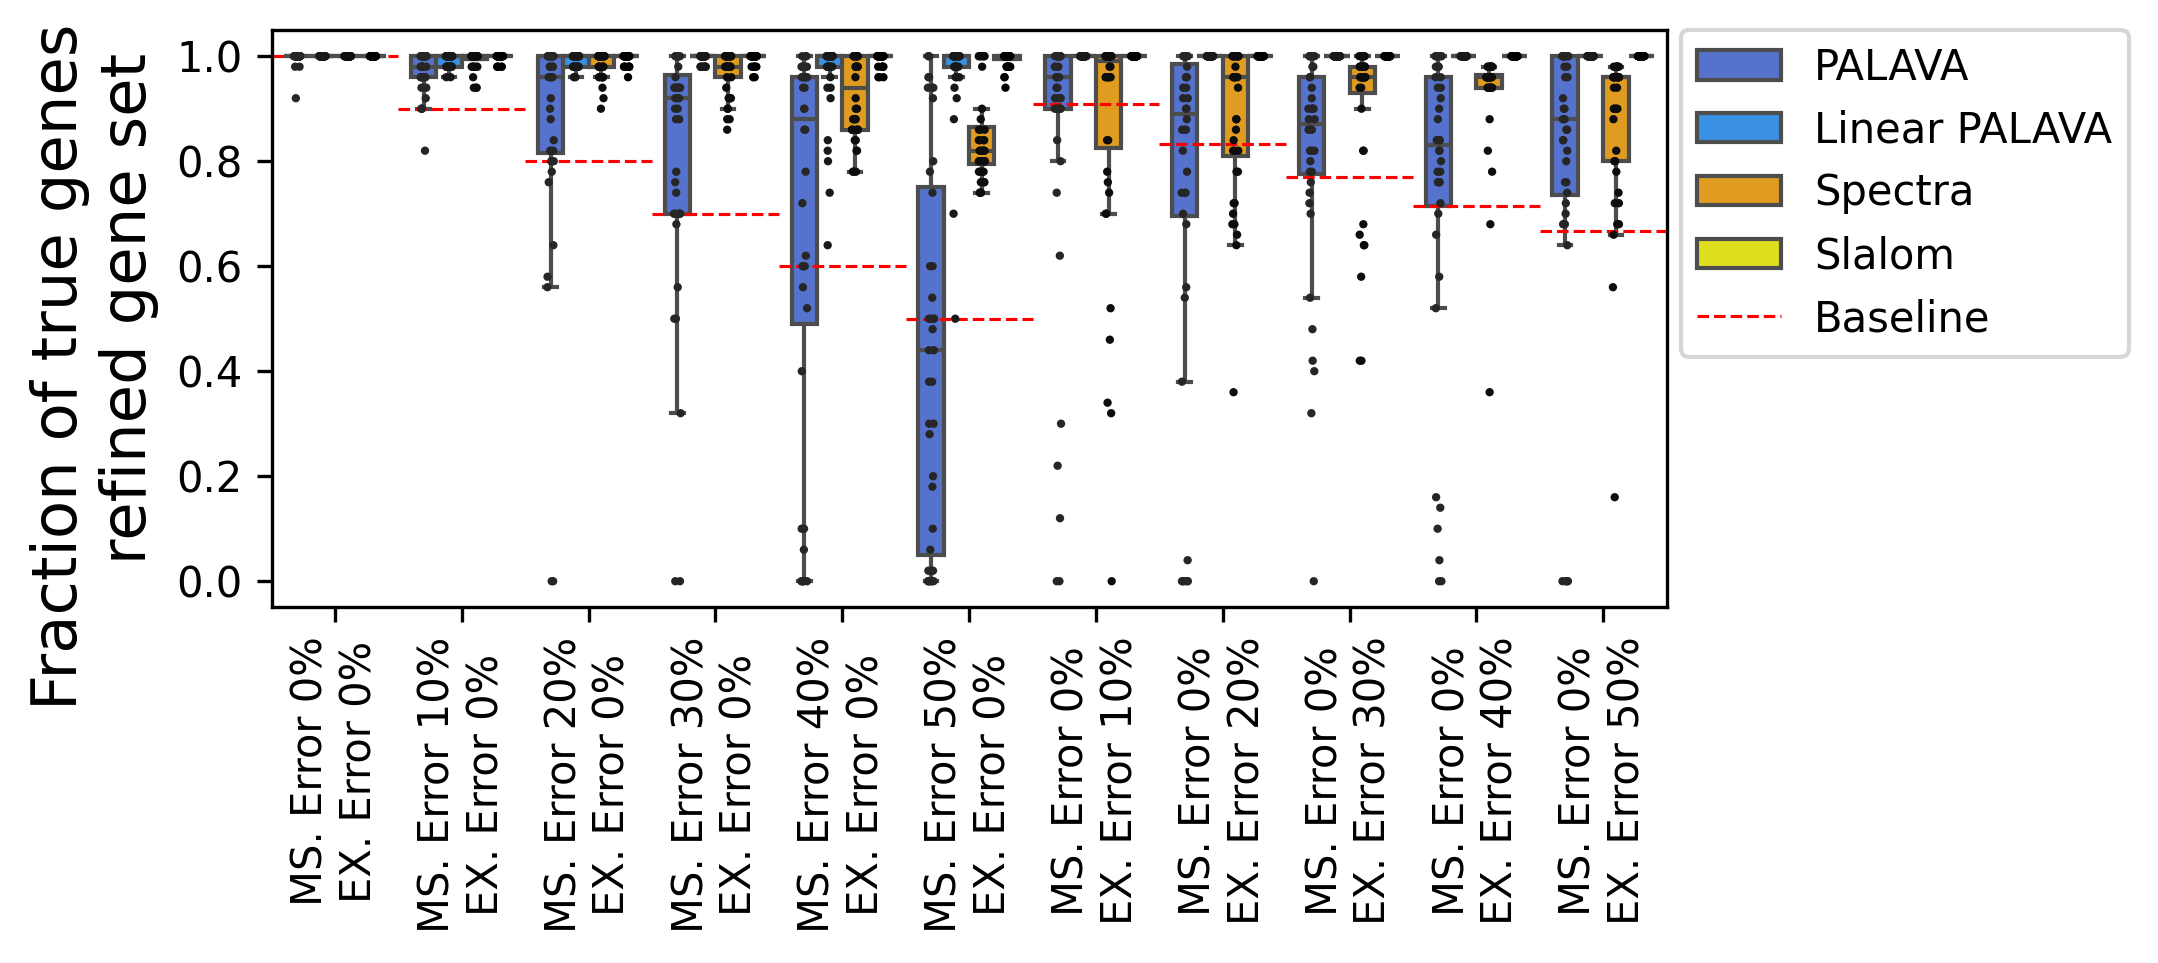

In [13]:

ERRORS_plot = ERRORS_ 

ERRORS_plot_labels =[]

for er in ERRORS_plot:
    
    if 'MS' in er:
        pattern = r'MS_(\d+)_EX_(\d+)'
        # Use re.findall to extract values
        fn_value, fp_value = re.findall(pattern, er)[0]
        if int(fn_value)==0 and fp_value==0:
            ERRORS_plot_labels.append('No error')
        else:
             ERRORS_plot_labels.append(f'MS. Error {fn_value}%\nEX. Error {fp_value}%')
        
    else:
        pattern = r'FN_(\d+)_FP_(\d+)'
        fn_value, fp_value = re.findall(pattern, er)[0]

        ERRORS_plot_labels.append(f'MS. Error {fn_value}%\nEX. Error {fp_value}%')

plot_dict = {method:[] for method in methods}
plot_dict['errors'] = []

for error in ERRORS_plot:
    for method in methods:
        for results in results_dict[method]['result_directorys']:
            if error in results:
                if  method==methods[0]:
                    plot_dict['errors'] += [ERRORS_plot_labels[ERRORS_plot.index(error)]] *num_facs_ann
                    

                top_gene_scores = results_dict[method][results]['fraction_of_GT_in_top_genes'].tolist()

                plot_dict[method] += top_gene_scores

#for method in ['no_anno_palava','no_anno_linear_palava']:
#    plot_dict[method] += [None] *(len(plot_dict['palava'])- len(plot_dict[method]))



# for method in ['no_anno_palava','no_anno_linear_palava_no_bias']:
#     plot_dict[method] += [None] *(len(plot_dict['palava'])- len(plot_dict[method]))


df = pd.DataFrame(plot_dict)

methods_to_plot = ['palava','linear_palava','spectra', 'slalom']  # 'palava',


df = pd.melt(df,id_vars=['errors'],value_vars=methods_to_plot,
             var_name='methods', value_name='Fraction of genes recovered')

# ['palava', 'linear_palava_no_bias', 'spectra', 'default_slalom']

new_method_names = ['PALAVA', 'Linear PALAVA', 'Spectra', 'Slalom' ] # 'PALAVA',
replacement_dict = { methods_to_plot[i]:new_method_names[i] for i in range(len(methods_to_plot))}
    
df= df.replace(replacement_dict)



colors_lst = ['royalblue','dodgerblue','orange', 'yellow']#, 'skyblue', 'darkblue', 'deepskyblue', 'orange', 'green']

custom_palette = {new_method_names[i]:colors_lst[i] for i in range(len(methods_to_plot))
  
}


import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 2.5), dpi =300) #for a bigger image
ax = sns.boxplot(
    x="errors", y='Fraction of genes recovered', hue='methods', data=df, palette=custom_palette, showfliers=False
)

baseline_dict = {}
baseline_dict['errors']= list(set(plot_dict['errors']))
baseline_dict['baseline'] = []


# baseline value data to plot
for er in baseline_dict['errors']:
    pattern = r'(?:MS\. Error|EX\. Error) (\d+)'#r'MS. Error (\d+)_EX. Error (\d+)'
        # Use re.findall to extract values
    ms_value, ex_value = re.findall(pattern, er)
    m = int(ms_value)/100
    s = int(ex_value)/100
    baseline_dict['baseline'] +=  [(1-m)/(1+s)]


# Add horizontal lines for baseline values
for error, baseline_value in zip(baseline_dict['errors'], baseline_dict['baseline']):
    x_pos = df[df['errors'] == error]['errors'].iloc[0]
    x_pos = ERRORS_plot_labels.index(x_pos)
    # Draw horizontal line
    width = 0.5
    plt.hlines(y=baseline_value, xmin=x_pos - width, xmax=x_pos + width, color='r', linestyle='--', label=f"Baseline", linewidth=0.75)



# Add the scatter plot 
sns.stripplot(
    x="errors", y='Fraction of genes recovered', hue='methods', data=df, size=2, jitter=True, palette="dark:black", dodge=True,legend = 'full'
)

plt.xlabel("", fontsize =15)
plt.ylabel("Fraction of true genes in \n refined gene set", fontsize =15)
plt.xticks(rotation=90)  # Rotate x labels to prevent overlapping
#plt.ylim([ 0.45, 1])
handles, labels = ax.get_legend_handles_labels()

l = plt.legend(handles[0:len(methods_to_plot)+1], labels[0:len(methods_to_plot)+1], bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.)

#plt.legend().set_visible(False)


plt.savefig('figures/method_comp_sim_with_small_num_active_factors_and_gens_frac_true_gene_set_genes.png', dpi = 150, bbox_inches="tight")

plt.show()



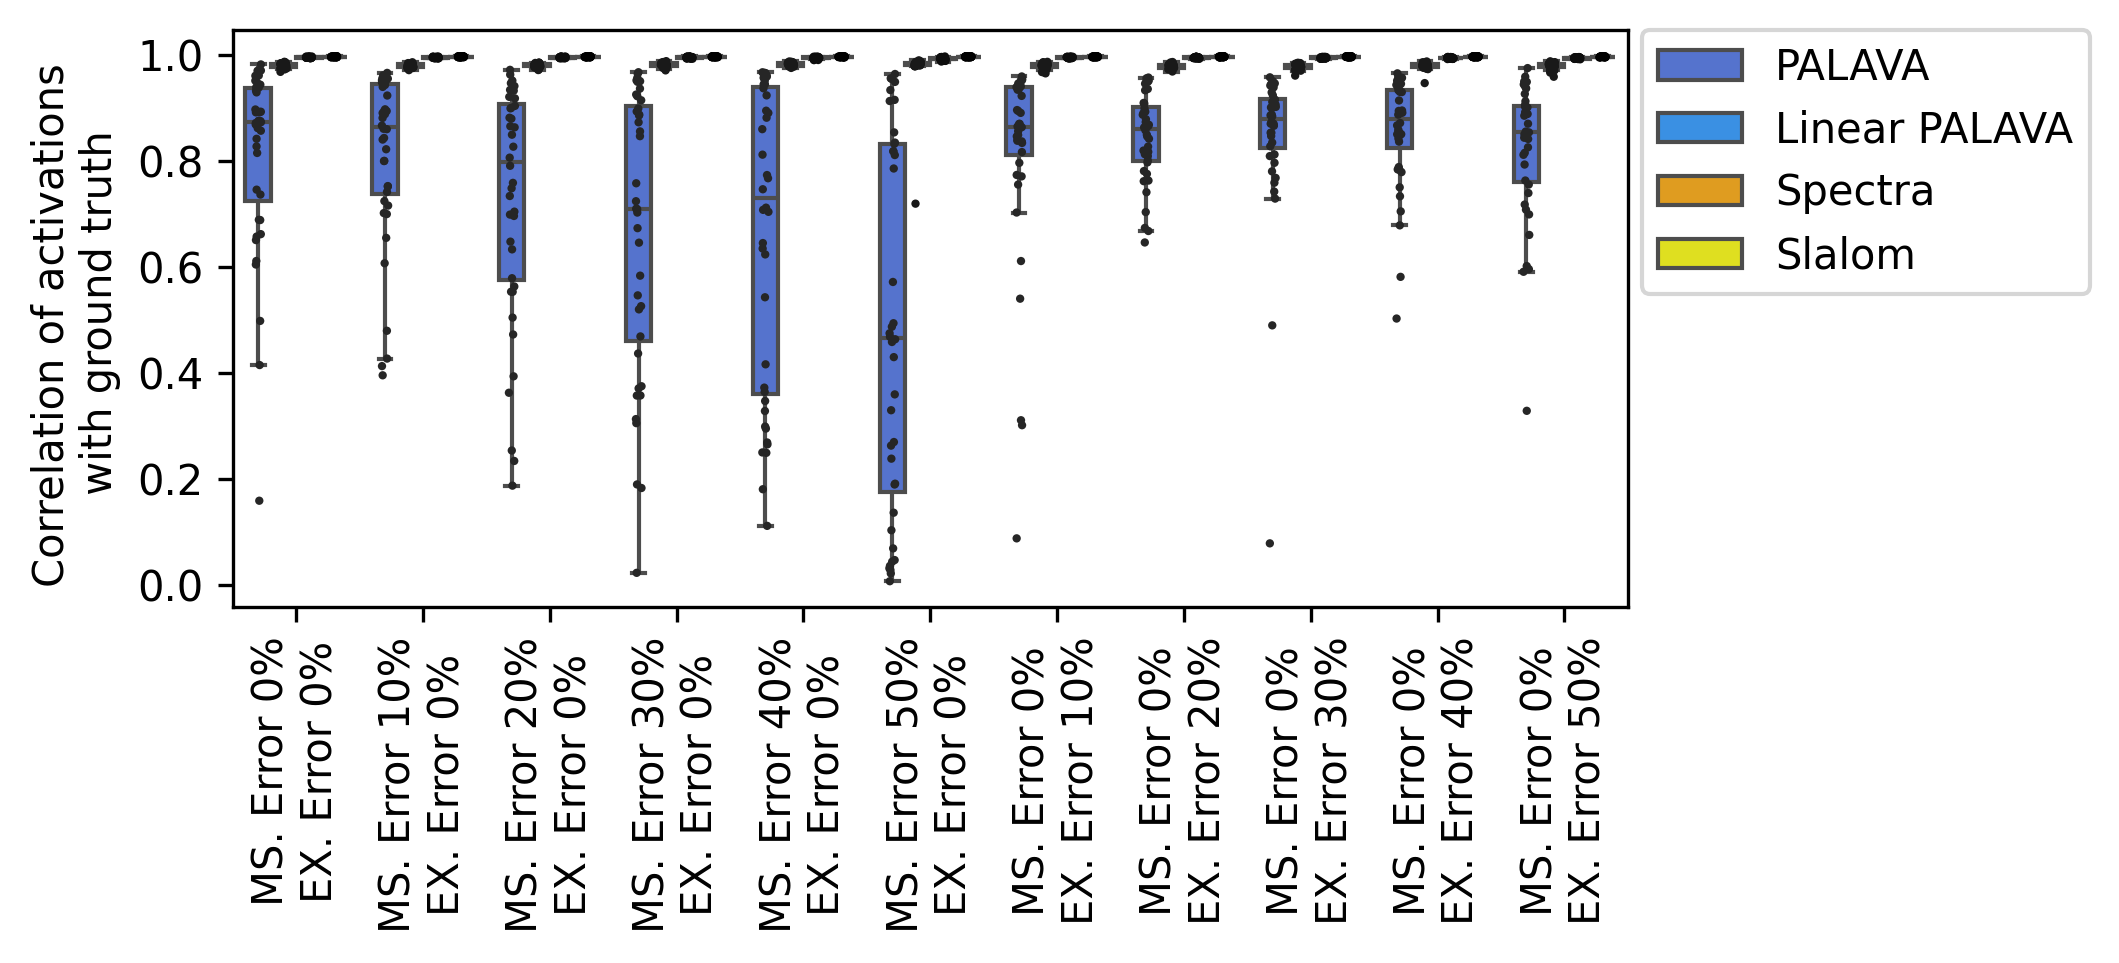

In [14]:

ERRORS_plot = ERRORS_ 

ERRORS_plot_labels =[]

for er in ERRORS_plot:
    
    if 'MS' in er:
        pattern = r'MS_(\d+)_EX_(\d+)'
        # Use re.findall to extract values
        fn_value, fp_value = re.findall(pattern, er)[0]
        if int(fn_value)==0 and fp_value==0:
            ERRORS_plot_labels.append('No error')
        else:
             ERRORS_plot_labels.append(f'MS. Error {fn_value}%\nEX. Error {fp_value}%')
        
    else:
        pattern = r'FN_(\d+)_FP_(\d+)'
        fn_value, fp_value = re.findall(pattern, er)[0]

        ERRORS_plot_labels.append(f'MS. Error {fn_value}%\nEX. Error {fp_value}%')

plot_dict = {method:[] for method in methods}
plot_dict['errors'] = []

for error in ERRORS_plot:
    for method in methods:
        for results in results_dict[method]['result_directorys']:
            if error in results:
                if  method==methods[0]:
                    plot_dict['errors'] += [ERRORS_plot_labels[ERRORS_plot.index(error)]] *num_facs_ann
                    

                top_gene_scores = results_dict[method][results]['latent_respresentation_correlation_with_gt'].tolist()

                plot_dict[method] += top_gene_scores




df = pd.DataFrame(plot_dict)



methods_to_plot = ['palava','linear_palava','spectra', 'slalom']  # 'palava',
df = pd.melt(df,id_vars=['errors'],value_vars=methods_to_plot,
             var_name='Errors', value_name='Correlation of activations with ground truth')




new_method_names = ['PALAVA', 'Linear PALAVA', 'Spectra', 'Slalom' ] # 'PALAVA',
replacement_dict = { methods_to_plot[i]:new_method_names[i] for i in range(len(methods_to_plot))}
    
df= df.replace(replacement_dict)

colors_lst = ['royalblue','dodgerblue','orange', 'yellow']#, 'skyblue', 'darkblue', 'deepskyblue', 'orange', 'green']

custom_palette = {new_method_names[i]:colors_lst[i] for i in range(len(new_method_names))
  
}

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 2.5), dpi =300) #for a bigger image
ax = sns.boxplot(
    x="errors", y='Correlation of activations with ground truth', hue='Errors', data=df, palette=custom_palette, showfliers=False
)

# Add the scatter plot with updated palette
sns.stripplot(
    x="errors", y='Correlation of activations with ground truth', hue='Errors', data=df, size=2, jitter=True, palette="dark:black", dodge=True,legend = 'full'
)


# Customize the plot
plt.xlabel("")
plt.ylabel("Correlation of activations \n with ground truth")
plt.xticks(rotation=90)  # Rotate x labels to prevent overlapping

handles, labels = ax.get_legend_handles_labels()

# When creating the legend, only use the first two elements
# to effectively remove the last two.
l = plt.legend(handles[0:len(methods_to_plot)], labels[0:len(methods_to_plot)], bbox_to_anchor=(1.01, 1), loc=2, borderaxespad=0.)


plt.savefig('figures/method_comp_sim_with_small_num_active_and_genes_corr_of_activations.png', dpi = 150, bbox_inches="tight")

plt.show()


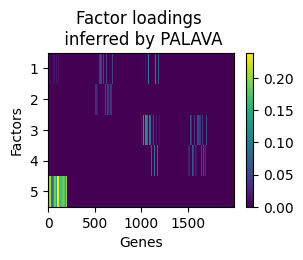

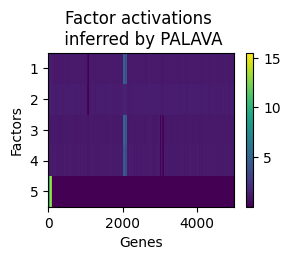

['538' '1020' '1155' '1075' '1077' '1037' '1149' '1074' '1086' '1083'
 '1146' '1194' '1068' '1033' '1178' '1156' '1025' '1144' '1073' '1062'
 '1153' '1154' '1027' '1102' '1181' '1035' '1169' '1046' '527' '1097'
 '681' '1193' '600' '1040' '541' '1038' '584' '533' '528' '685' '1069'
 '583' '522' '513' '561' '677' '689' '687' '696' '593' '572' '625' '548'
 '633' '693' '605' '659' '664' '512' '598' '553' '550' '698' '651' '688'
 '500' '1014' '501' '590' '531' '536' '596' '613' '691' '551' '683' '601'
 '639' '610' '591' '611' '642' '678' '579' '562' '521' '574' '692' '554'
 '510' '629' '569' '589' '1042' '1021' '623' '632' '581' '1087' '787'
 '1129' '1164' '1058' '1139' '1005' '1172' '1108' '1135' '1130' '1285'
 '1041' '1023' '1084' '1112' '452' '1535' '1720' '1055' '1100' '1022'
 '1056' '1803' '839' '615' '1960' '1553' '844' '1148' '1509' '379' '1085'
 '1032' '784' '1224' '1518' '285' '1044' '557' '1862' '1408' '458' '1206'
 '1375']


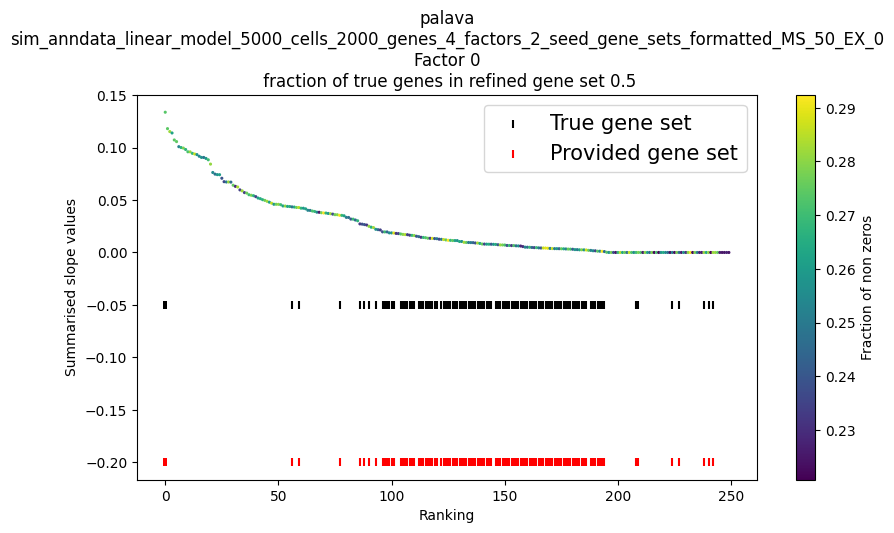

['452' '59' '302' '1348' '1864' '1005' '1720' '1774' '708' '1897' '881'
 '902' '391' '787' '811' '817' '393' '1669' '1791' '265' '977' '1135'
 '999' '784' '1227' '1991' '1977' '89' '317' '470' '934' '807' '1772'
 '216' '1408' '1912' '484' '327' '1877' '991' '1597' '940' '1892' '1589'
 '882' '1790' '1794' '1775' '1248' '392' '1367' '1009' '1607' '1761'
 '1346' '348' '458' '1862' '1898' '1992' '1540' '1859' '462' '850' '721'
 '1997' '1694' '702' '218' '1194' '703' '323' '1473' '1055' '1705' '1596'
 '1104' '337' '1670' '986' '441' '1242' '1981' '430' '712' '401' '972'
 '63' '1203' '1451' '758' '914' '1229' '1809' '771' '224' '1885' '1636']


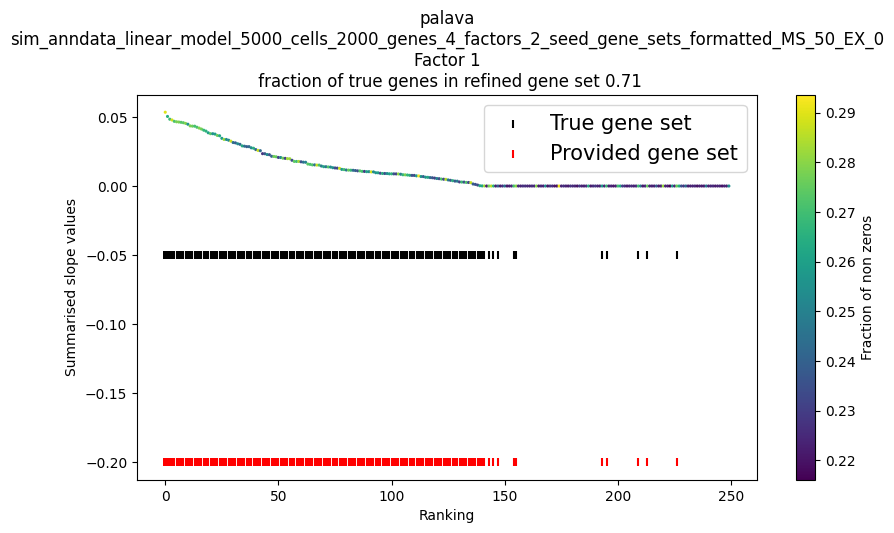

['1676' '1679' '1535' '1656' '1520' '1553' '1649' '1680' '1629' '1592'
 '1524' '1634' '1637' '1657' '1621' '1503' '1671' '1695' '1557' '1605'
 '1670' '1541' '1682' '1572' '1698' '1602' '1691' '1548' '1598' '1609'
 '1642' '1527' '1610' '1669' '1566' '1586' '1652' '1635' '1523' '1620'
 '1631' '1681' '1668' '1640' '1550' '1549' '1595' '1644' '1619' '1534'
 '1666' '1537' '1672' '1585' '1690' '279' '719' '1331' '1636' '1836'
 '1646' '1547' '1494' '538' '1762' '226' '1910' '317' '1436' '1471' '996']


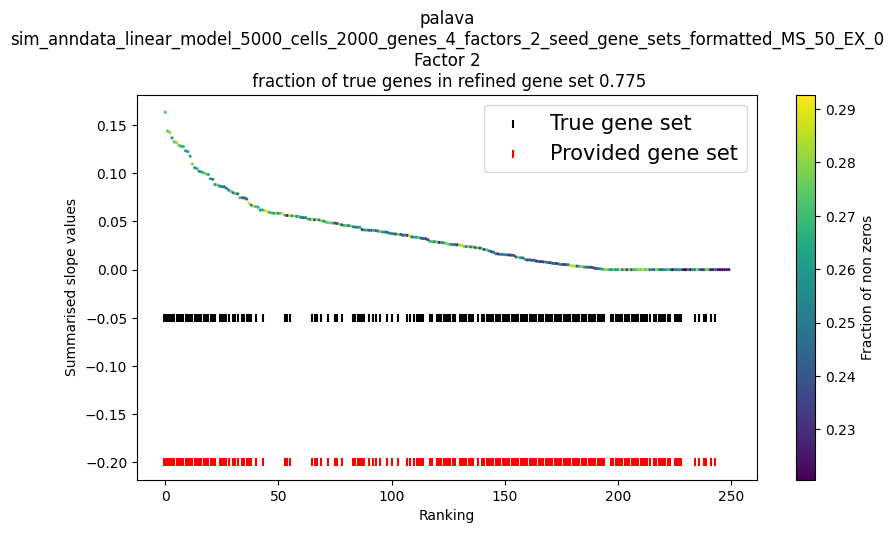

['1023' '1172' '1139' '1140' '1164' '1071' '1015' '1087' '1012' '1165'
 '1171' '1191' '1130' '1106' '1158' '1022' '1166' '1005' '1124' '1143'
 '1186' '1056' '1011' '1123' '1163' '1116' '1182' '1100' '1055' '1007'
 '1149' '1075' '1077' '1086' '1178' '1194' '1083' '538' '1020' '452'
 '1762' '1348' '1144' '546' '1089' '1475' '1034' '1046' '1066' '1169'
 '1059' '558' '1910' '955' '1093' '1174' '1062' '206' '134' '633' '1248'
 '1037' '547' '792' '1120' '1136' '198' '1862' '280' '1108' '447' '1045'
 '853' '1044' '128' '1018' '788' '516' '1092' '287' '1068' '1030' '1112'
 '1923' '522' '744' '719' '659' '1031' '1121' '1307' '1094' '86' '1220'
 '323' '1196' '1135' '801' '1183' '44']


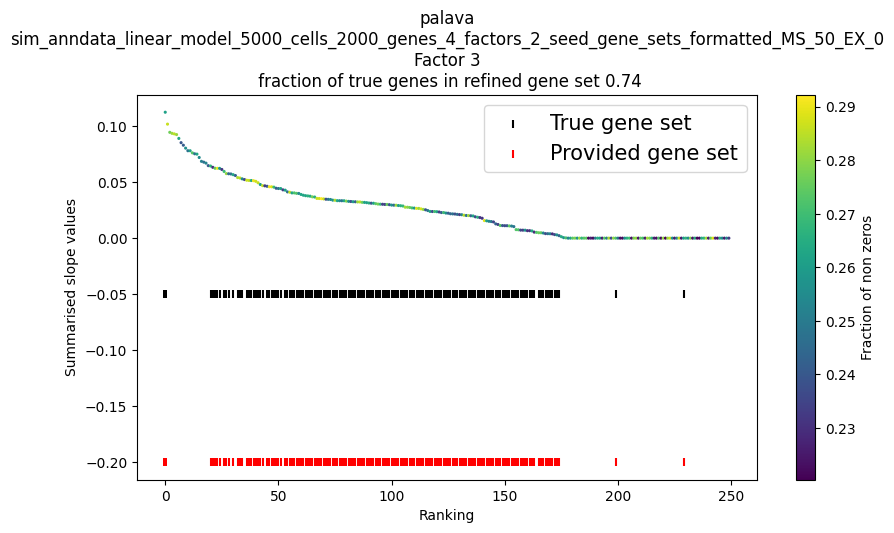

['101' '118' '29' '128' '8' '196' '3' '131' '83' '17' '141' '78' '117'
 '199' '172' '72' '22' '86' '152' '162' '145' '51' '61' '105' '43' '171'
 '190' '87' '102' '137' '146' '177' '167' '42' '82' '134' '71' '156' '197'
 '132' '130' '181' '198' '151' '169' '166' '57' '60' '27' '9' '54' '165'
 '66' '80' '14' '176' '56' '133' '75' '12' '52' '15' '34' '0' '138' '161'
 '187' '124' '99' '10' '67' '113' '25' '106' '139' '182' '49' '98' '136'
 '154' '38' '185' '95' '142' '111' '164' '170' '129' '107' '44' '37' '73'
 '7' '30' '48' '4' '94' '76' '123' '127' '904' '1654' '507' '1667' '1166'
 '1232' '1549' '1417' '888' '1152' '1030' '978' '1368' '264' '1505' '1914'
 '1260' '1711' '640' '848' '1676' '399' '767' '1036' '383' '1038' '590'
 '356' '1265' '343' '1000' '1408' '1983' '324' '1736' '1677' '488' '1534'
 '630' '1959' '971' '1037' '697' '242' '780' '1501' '588' '232' '442'
 '800']


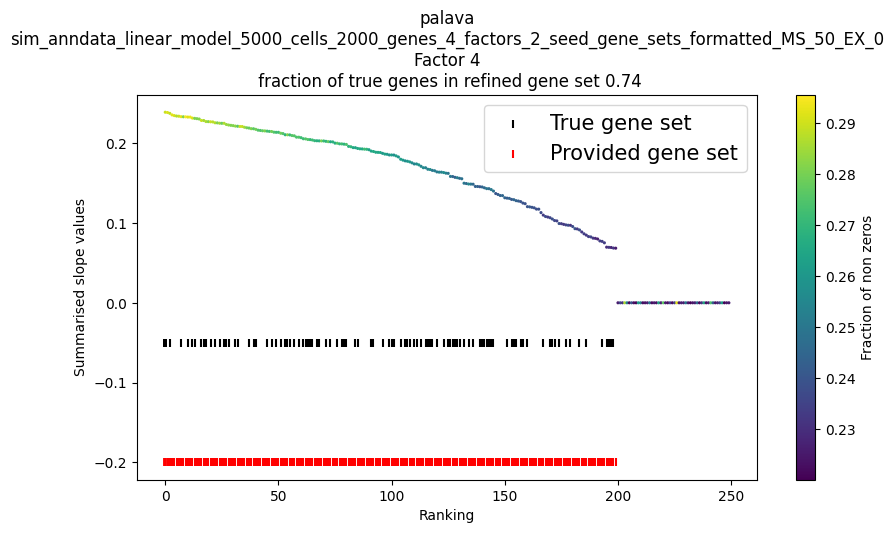

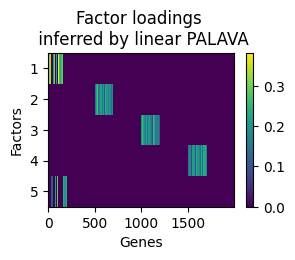

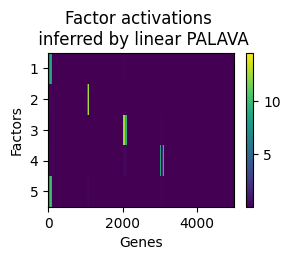

['1021' '576' '948' '1743' '1128' '1059' '317' '685' '1805' '1030' '1881'
 '1902' '1314' '373' '1413' '1318' '540' '1521' '985' '537' '1504' '709'
 '1027' '802' '232' '599' '356' '246' '1505' '1558' '648' '1649' '838'
 '1969' '1181' '215' '491' '1518' '490' '212' '1327' '403' '1377' '315'
 '930' '848' '962' '201' '865' '389']


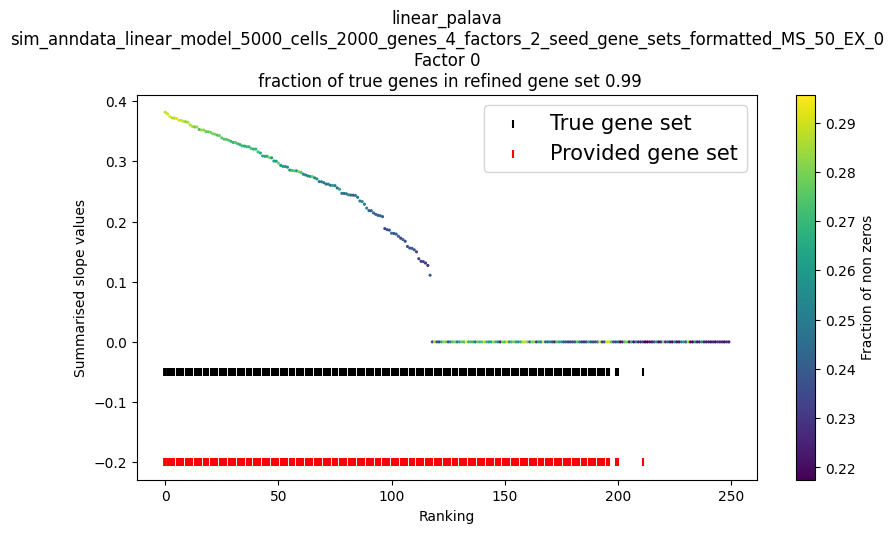

['1471' '1921' '54' '468' '724' '415' '364' '1211' '874' '358' '1085'
 '1689' '305' '1647' '1740' '1785' '357' '1102' '1619' '340' '1660' '1199'
 '1538' '995' '480' '1140' '886' '905' '1930' '26' '38' '710' '823' '1070'
 '1957' '1133' '1266' '1497' '445' '1007' '1024' '1027' '1994' '956' '921'
 '1025' '1490' '1213' '988' '309']


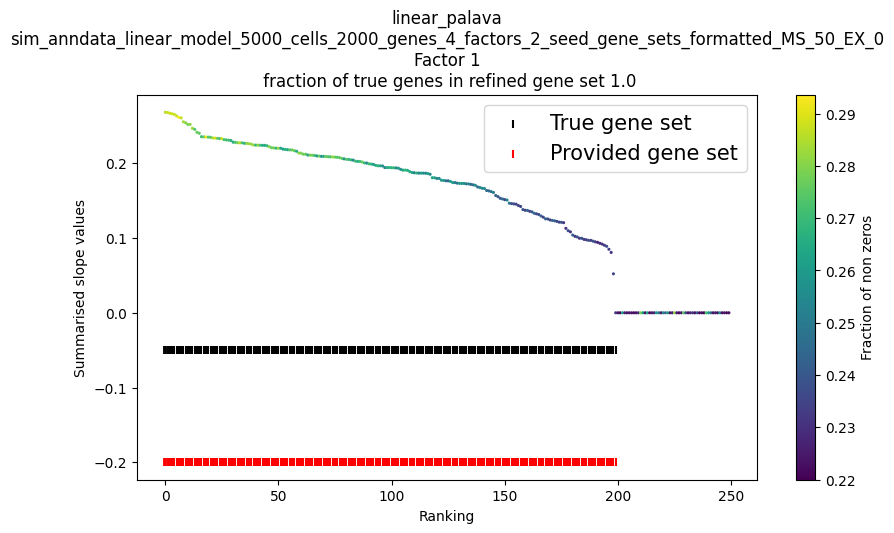

['1235' '5' '384' '17' '1744' '1956' '784' '595' '55' '245' '801' '156'
 '1279' '738' '1692' '185' '1348' '1821' '578' '545' '416' '1471' '249'
 '877' '59' '734' '741' '422' '407' '62' '289' '317' '1688' '957' '1825'
 '143' '864' '93' '291' '1203' '546' '1904' '348' '1588' '1811' '1918'
 '1359' '1319' '1639' '163']


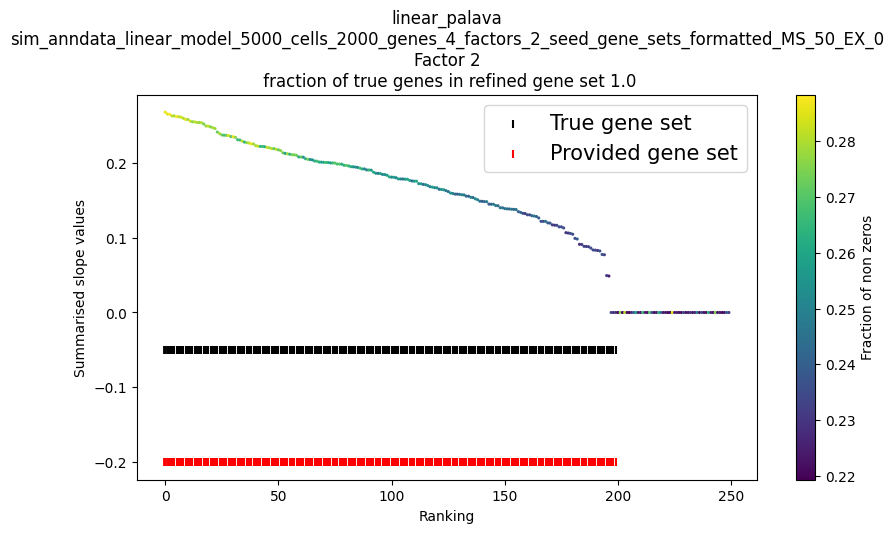

['348' '1345' '459' '288' '983' '1772' '65' '1150' '539' '1833' '200'
 '355' '971' '1802' '353' '18' '730' '1925' '558' '293' '1399' '198' '472'
 '1806' '643' '118' '960' '1144' '1830' '1867' '298' '1749' '627' '1890'
 '588' '1822' '603' '761' '662' '1255' '789' '1387' '885' '182' '1183'
 '1917' '53' '134' '495' '1858']


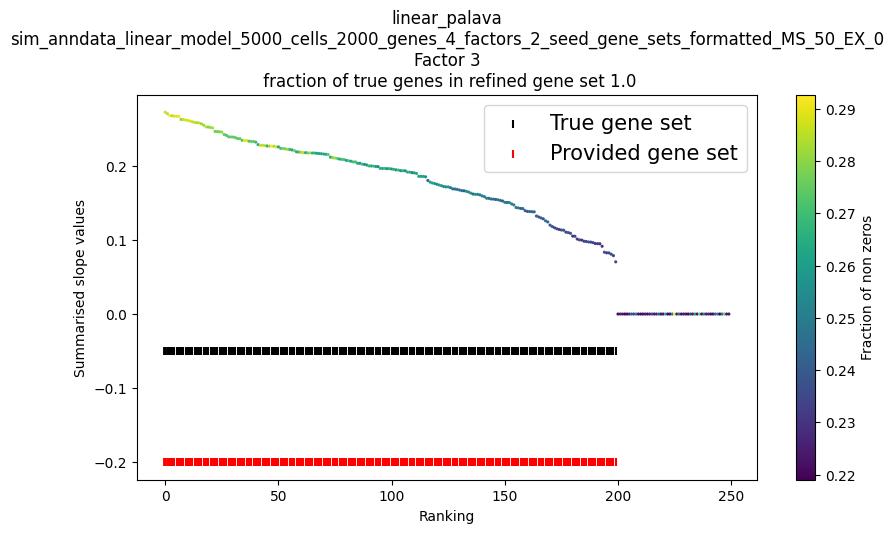

['3' '131' '101' '128' '118' '117' '8' '78' '83' '152' '29' '86' '22' '17'
 '141' '199' '72' '43' '61' '172' '51' '105' '137' '190' '171' '71' '156'
 '177' '167' '42' '82' '9' '132' '169' '197' '151' '165' '130' '198' '166'
 '54' '66' '57' '60' '80' '14' '56' '176' '75' '52' '15' '0' '187' '34'
 '138' '99' '161' '10' '25' '113' '139' '49' '154' '38' '185' '142' '95'
 '129' '170' '111' '164' '73' '44' '48' '7' '76' '30' '37' '4' '127' '133'
 '145' '181' '162' '27' '1028' '102' '12' '124' '709' '196' '136' '1654'
 '106' '107' '1318' '373' '1881' '232' '1649' '87' '537' '848' '1327'
 '919' '1260' '67' '1278' '1928' '1686' '182' '1633' '431' '228' '1630'
 '576' '1657' '1030' '1635' '1723' '855' '626' '815' '1505' '146' '749'
 '1922' '214' '1002' '778' '701' '523' '507' '873' '989' '201' '1172'
 '1667' '1407' '1569' '249' '352' '1521' '1501' '1359' '1736' '665' '438'
 '785' '1518' '1651' '1011' '648' '1836' '1379' '1027' '399' '134' '1499']


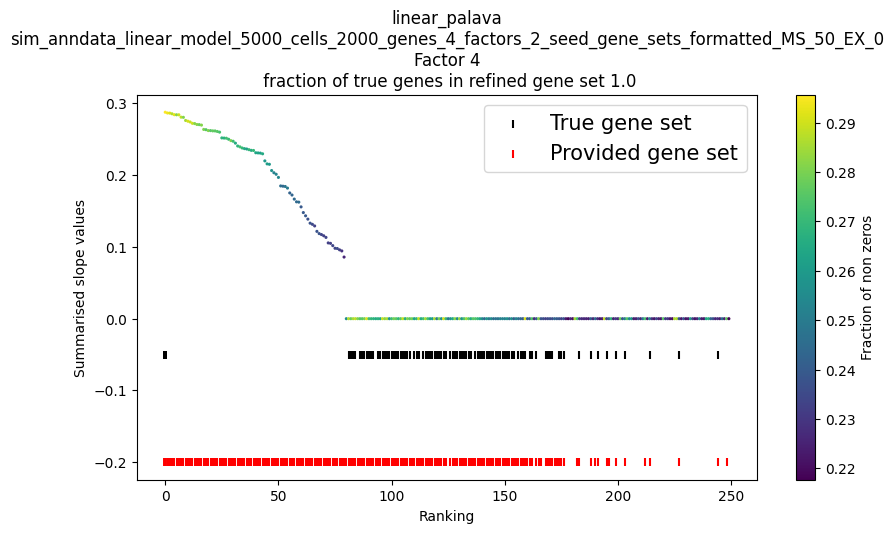

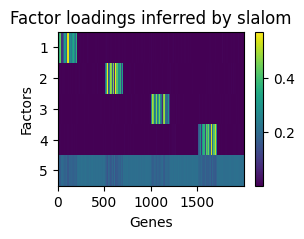

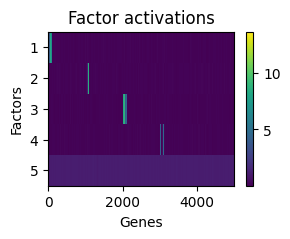

['1260' '904' '510' '1494' '356' '318' '1759' '1002' '530' '1649' '507'
 '285' '1564' '1687' '398' '1884' '1235' '859' '1709' '872' '537' '1686'
 '1170' '242' '1423' '780' '1045' '485' '1061' '1166' '1918' '1635' '1168'
 '714' '1000' '975' '759' '1819' '271' '1181' '1030' '766' '664' '1336'
 '315' '1480' '1540' '1913' '489' '1667']


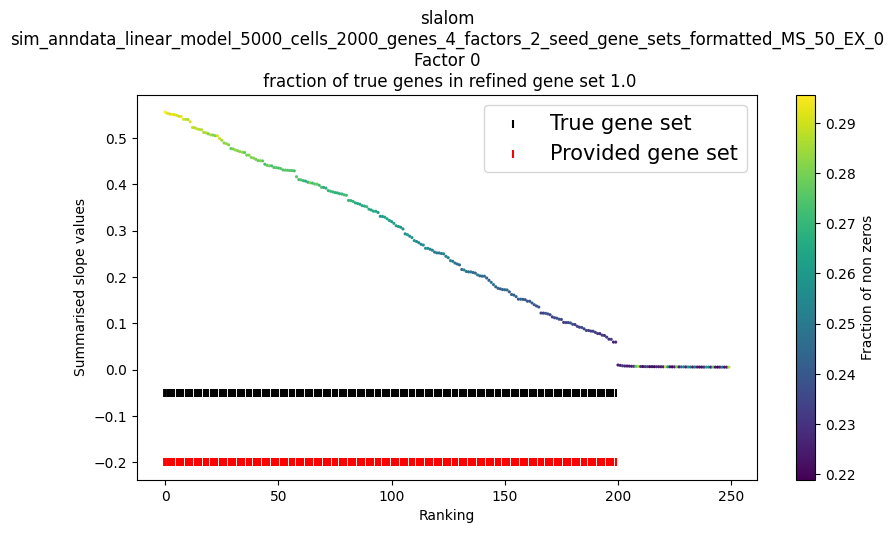

['1854' '874' '468' '419' '818' '1480' '295' '1203' '977' '1444' '45'
 '229' '1381' '1471' '933' '1229' '1000' '1234' '1674' '1935' '1168' '19'
 '1063' '76' '296' '1877' '422' '1336' '1594' '1194' '1499' '1768' '1884'
 '18' '1824' '54' '1211' '472' '1101' '992' '1070' '887' '473' '1720'
 '1178' '1879' '99' '1959' '1832' '1223']


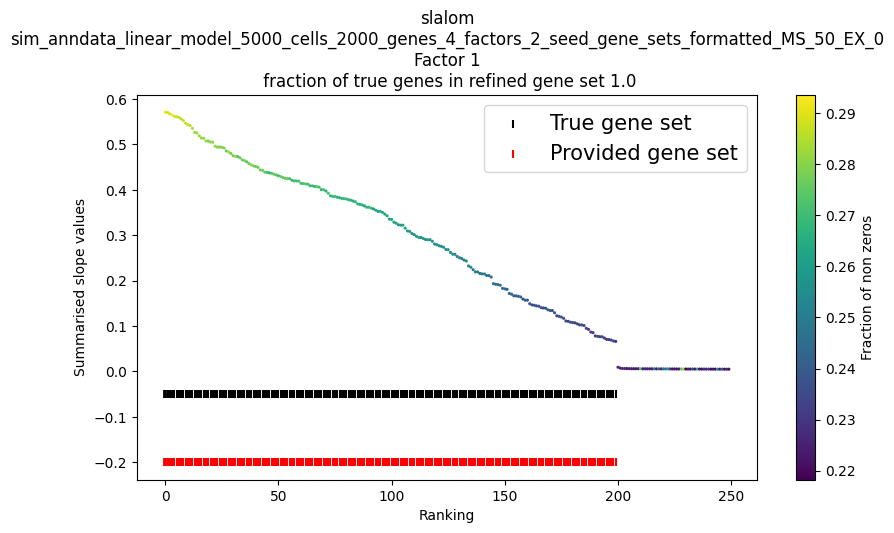

['1634' '520' '5' '835' '442' '956' '1961' '1608' '1382' '1665' '1642'
 '273' '950' '594' '583' '1585' '975' '1876' '394' '1344' '1956' '1850'
 '388' '1467' '1249' '345' '495' '111' '786' '566' '480' '1437' '275'
 '772' '126' '516' '200' '1207' '741' '1795' '1285' '1513' '185' '312'
 '1670' '99' '1347' '1601' '1384' '1782']


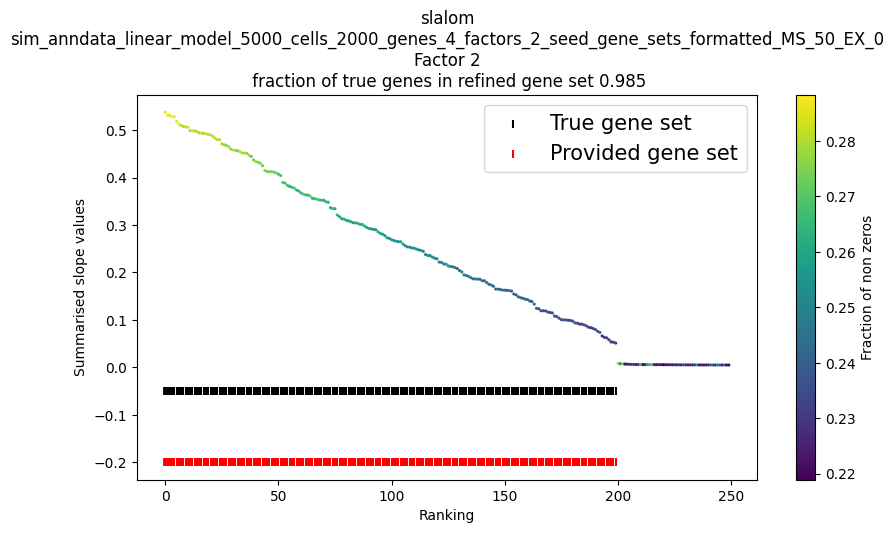

['630' '45' '1345' '239' '348' '975' '114' '1256' '1914' '118' '65' '264'
 '857' '638' '1131' '862' '1245' '323' '462' '413' '138' '288' '1303'
 '1220' '1172' '1413' '885' '1224' '1850' '1022' '750' '51' '32' '923'
 '230' '124' '1053' '473' '760' '971' '874' '1783' '615' '1447' '200'
 '1772' '1113' '445' '952' '564']


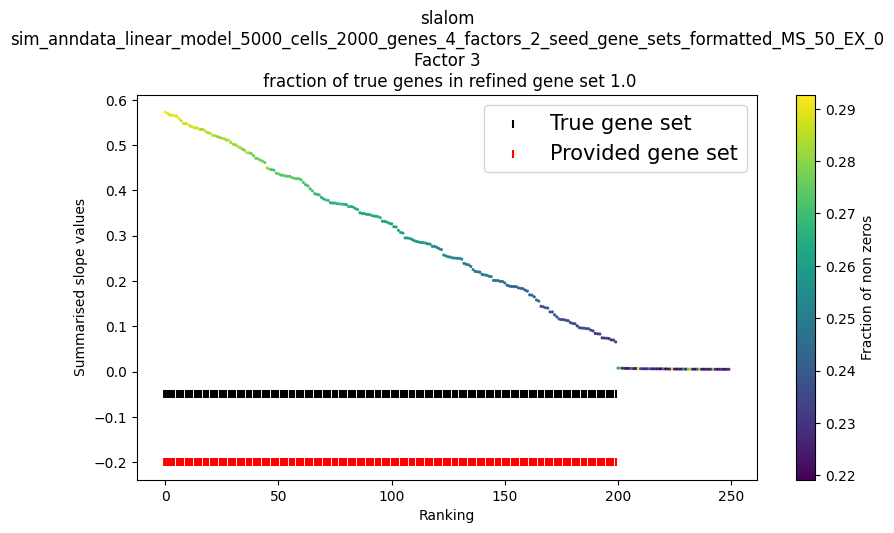

['589' '1644' '1065' '873' '1761' '930' '271' '844' '1091' '294' '306'
 '428' '484' '493' '827' '912' '949' '746' '251' '727' '1333' '1922'
 '1438' '1995' '223' '1193' '1288' '1972' '1854' '1461' '331' '1873'
 '1961' '742' '869' '1953' '1300' '1433' '982' '368' '423' '768' '865'
 '337' '939' '1204' '1856' '942' '920' '863' '1871' '1815' '345' '239'
 '378' '1420' '1328' '418' '339' '722' '1902' '784' '1853' '468' '1820'
 '204' '1494' '1275' '426' '1377' '419' '969' '845' '1844' '1290' '1306'
 '780' '1315' '726' '1772' '351' '1440' '357' '275' '1206' '1281' '1447'
 '857' '1218' '1291' '897' '1215' '789' '1378' '1496' '1943' '812' '1350'
 '420' '927' '408' '319' '823' '1346' '1762' '1431' '1220' '1831' '1750'
 '1765' '1786' '1245' '358' '1887' '1469' '314' '902' '1733' '1436' '752'
 '847' '1747' '344' '303' '1904' '846' '1816' '1708' '307' '709' '470'
 '211' '1974' '391' '312' '848' '1965' '386' '254' '843' '1302' '1491'
 '1915' '1935' '227' '1881' '951' '311' '900' '1222' '1265' '876' '1

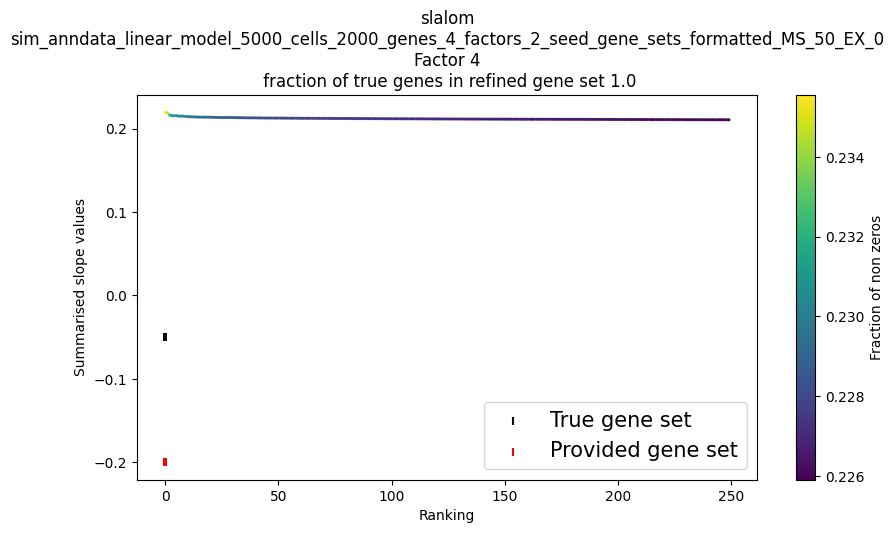

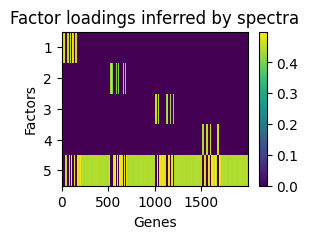

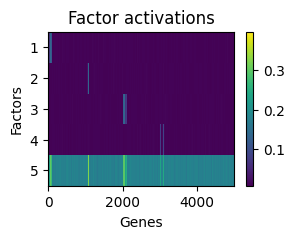

['1686' '1071' '1037' '1080' '1033' '1649' '1669' '1656' '1621' '672'
 '693' '623' '687' '1559' '1554' '614' '683' '584' '553' '1155' '625'
 '1679' '1676' '1127' '659' '1149' '1655' '1535' '1691' '647' '1146'
 '1587' '548' '1196' '1697' '530' '1089' '1529' '1506' '1009' '501' '1671'
 '536' '681' '1063' '1634' '1100' '1523' '1582' '1657' '1074' '1182'
 '1585']


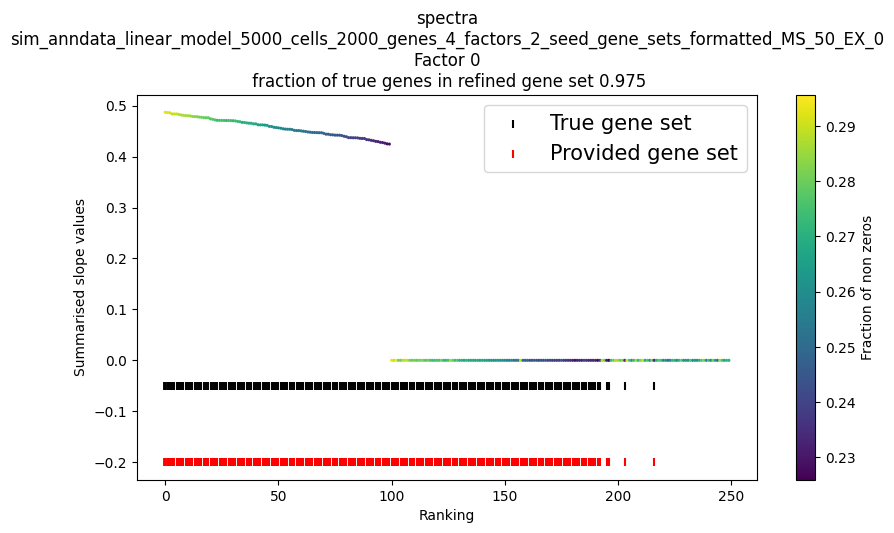

['1625' '1672' '22' '3' '1071' '1033' '1646' '1686' '1524' '82' '78'
 '1554' '1671' '152' '145' '1074' '1155' '1559' '1535' '1599' '1130'
 '1037' '1684' '117' '1682' '177' '1520' '1649' '29' '1124' '1146' '80'
 '1587' '169' '141' '1621' '1182' '1080' '1642' '176' '1691' '162' '1009'
 '60' '1149' '198' '132' '72' '165' '1089' '1079' '166' '1560' '1679'
 '1063' '1529' '57' '1506' '171' '1656' '83']


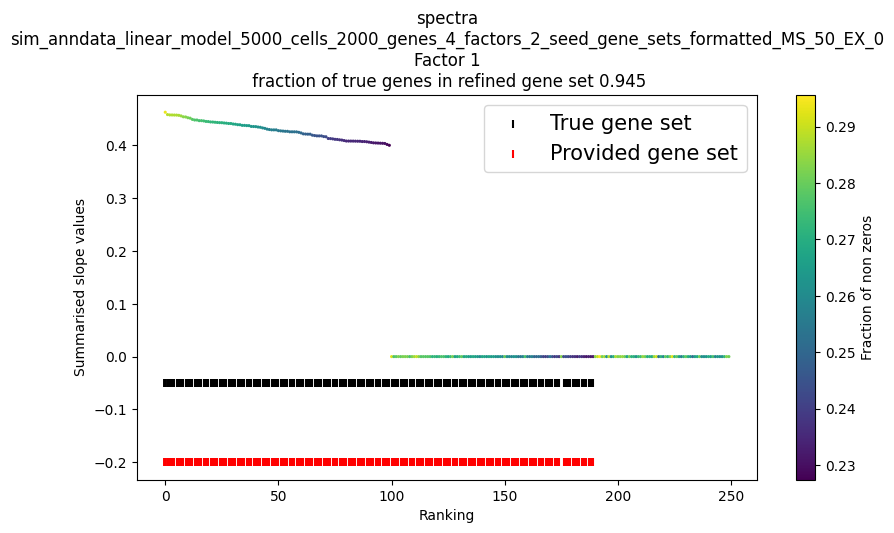

['584' '614' '29' '22' '583' '572' '683' '134' '687' '575' '169' '78'
 '1554' '600' '530' '82' '43' '544' '17' '1649' '1671' '198' '623' '1524'
 '141' '681' '1587' '8' '1599' '625' '151' '3' '1684' '1682' '162' '668'
 '536' '521' '165' '501' '171' '196' '1655' '72' '66' '1691' '57' '548'
 '83' '1592' '1697' '1672' '131' '132' '659' '553' '611']


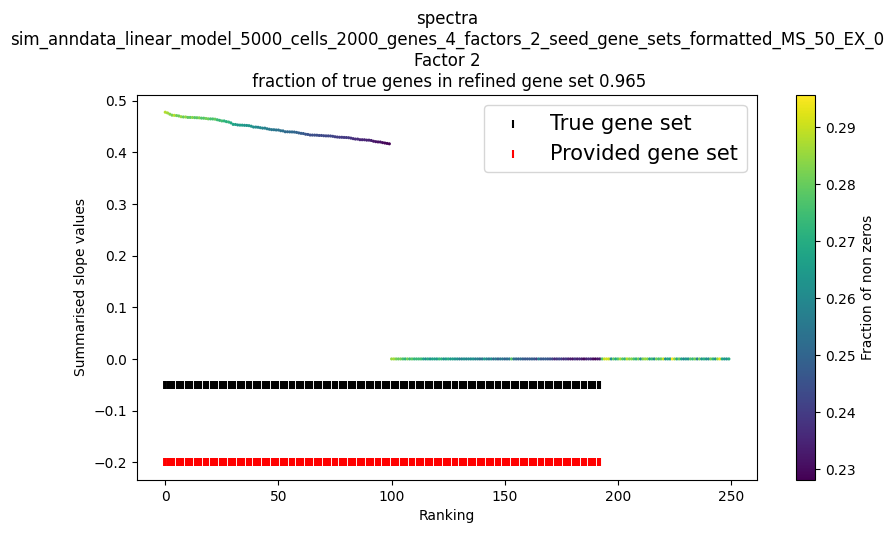

['530' '3' '1033' '600' '1130' '672' '1146' '17' '72' '152' '536' '501'
 '1181' '171' '1071' '575' '1080' '1073' '29' '8' '683' '614' '521' '548'
 '145' '693' '1007' '1037' '83' '1155' '691' '1021' '659' '1149' '1086'
 '117' '56' '198' '1009' '1063' '681' '151' '80' '583' '82' '169' '167'
 '647' '1074' '1182' '656' '131']


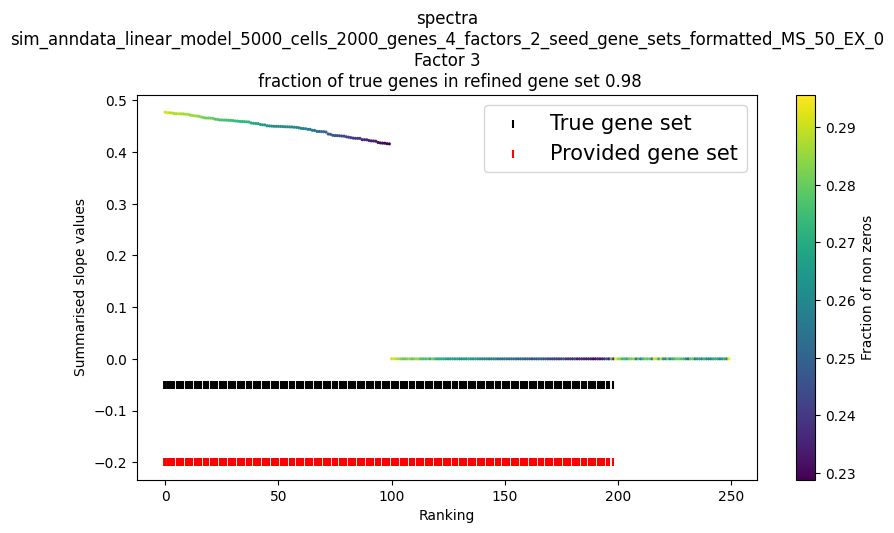

['3' '131' '1621' '118' '590' '101' '1509' '29' '1680' '22' '614' '8' '86'
 '1582' '1686' '597' '78' '128' '1033' '1172' '1641' '687' '1649' '152'
 '1684' '1164' '1672' '1671' '600' '1656' '1554' '596' '574' '527' '552'
 '141' '677' '196' '1155' '17' '1140' '117' '1194' '72' '1071' '145' '43'
 '83' '1153' '633' '541' '1120' '572' '172' '162' '1634' '1080' '42'
 '1669' '1587' '1609' '551' '682' '1548' '568' '1085' '1053' '661' '1086'
 '575' '199' '528' '134' '581' '501' '530' '603' '105' '593' '691' '584'
 '561' '672' '1139' '664' '1679' '1021' '1527' '1676' '137' '102' '1657'
 '190' '51' '681' '1037' '61' '1020' '146' '1077' '623' '538' '620' '1130'
 '694' '171' '1108' '87' '1182' '1007' '169' '651' '1535' '177' '1592'
 '1146' '82' '669' '555' '1691' '1559' '1585' '567' '1557' '533' '1062'
 '167' '1009' '197' '1598' '130' '166' '625' '1682' '611' '683' '1520'
 '688' '1629' '636' '132' '71' '1685' '668' '1068' '512' '678' '1129'
 '531' '1642' '156' '1083' '1581' '685' '198' '1074' '1566

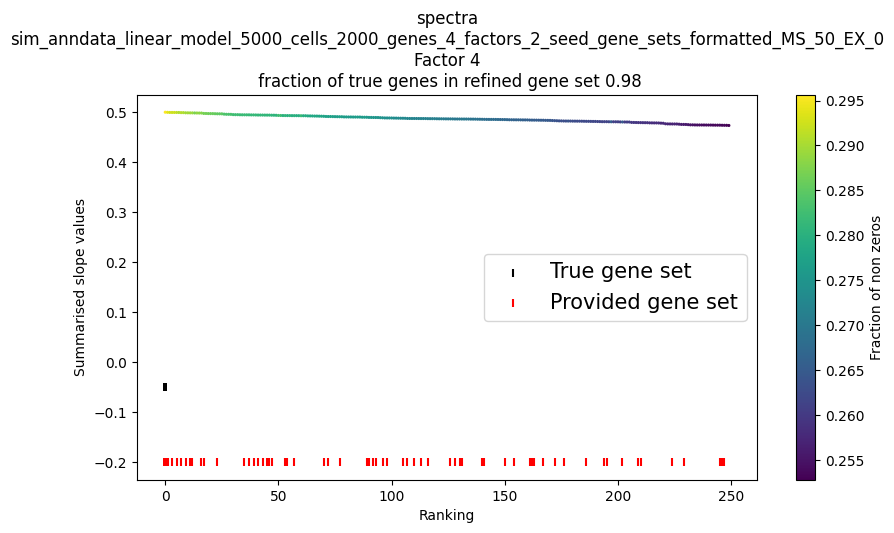

In [27]:




def sort_based_on_first_row(matrix):
    sorted_indices = np.argsort(-matrix[0])
    # Rearrange the columns based on the sorted indices
    sorted_matrix = matrix[:, sorted_indices]
    return  sorted_matrix




adata_to_rank_plot =['sim_anndata_linear_model_5000_cells_2000_genes_4_factors_2_seed_gene_sets_formatted_MS_50_EX_0']


adata = results_dict['adata']['sim_anndata_linear_model_5000_cells_2000_genes_4_factors_2_seed_gene_sets_formatted_MS_50_EX_0']


for method in ['palava','linear_palava','slalom','spectra']:# methods:
    flag =1
    for fac in [0,1,2,3,4]:
        for adata_dr in adata_to_rank_plot:
            
            
            if fac < 4:
                fraction_of_GT_in_top_genes = results_dict[method][adata_dr]['fraction_of_GT_in_top_genes'][fac]
                pathways_bool_no_error = results_dict['adata'][adata_dr].uns[ 'Ground truth gene sets'][:,fac]
                pathways_bool = results_dict['adata'][adata_dr].uns['Ground truth gene sets'][:,fac]

            else:
                pathways_bool_no_error = results_dict['adata'][adata_dr].uns['Pathways with error'][:,0]
                pathways_bool = results_dict['adata'][adata_dr].uns['Ground truth gene sets'][:,0]

            fac_loadings = np.abs(results_dict[method][adata_dr]['factor_loadings'])
            activations = np.abs(results_dict[method][adata_dr]['latent_representation'])

            if flag ==1:
                plt.figure(figsize=(3, 2)) 

                plt.imshow(fac_loadings, aspect ='auto', interpolation ='none')
                plt.title(method+' fac_loadings')
                plt.ylabel('Factors')
                plt.title('Factor loadings inferred by ' + method)
                plt.xlabel('Genes')
                plt.yticks([0, 1, 2, 3, 4], [1, 2, 3, 4, 5])
                plt.colorbar()


                if method == 'palava':
                    plt.title('Factor loadings \n inferred by PALAVA')
                  #  plt.savefig('figures/sim_small_num_cell_active_palava_inferred_actor_loading.png', dpi=300, bbox_inches='tight')

                if method == 'linear_palava':
                    plt.title('Factor loadings \n inferred by linear PALAVA')
                #    plt.savefig('figures/sim_small_num_cell_active_linear_palava_inferred_actor_loading.png', dpi=300, bbox_inches='tight')

                plt.show()
                plt.close()


                
                plt.figure(figsize=(3, 2)) 

                plt.imshow(activations.T, aspect ='auto', interpolation ='none')
                plt.title(method+ ' activations')
                plt.ylabel('Factors')
                plt.title('Factor activations')
                plt.xlabel('Genes')
                plt.yticks([0, 1, 2, 3, 4], [1, 2, 3, 4, 5])
                plt.colorbar()

                if method == 'palava':
                    plt.title('Factor activations \n inferred by PALAVA')
                   # plt.savefig('figures/sim_small_num_cell_active_palava_inferred_actor_activations.png', dpi=300, bbox_inches='tight')

                if method == 'linear_palava':
                    plt.title('Factor activations \n inferred by linear PALAVA')
                  #  plt.savefig('figures/sim_small_num_cell_active_linear_palava_inferred_actor_activations.png', dpi=300, bbox_inches='tight')

                plt.show()
                plt.close()
                flag =0
            #data = results_dict['adata'][adata_dr].X
            data = results_dict['adata'][adata_dr].layers['logcounts']


            fac_loadings_per_fac = fac_loadings[fac,:]
          #  print(fac_loadings_per_fac)
            
            frac_zeros =    np.mean(data, axis = 0) #/ data.shape[1]
        
            fac_loadings_per_fac_and_de_no_error = np.concatenate((fac_loadings_per_fac[None], pathways_bool_no_error[None],pathways_bool[None], frac_zeros[None], adata.var.index.to_numpy()[None]),axis = 0 )
            fac_loadings_per_fac_and_de_no_error = sort_based_on_first_row(fac_loadings_per_fac_and_de_no_error)
           
           
        
            n_top_genes =250
        
            y = fac_loadings_per_fac_and_de_no_error[0][:n_top_genes] #np.sort(fac_loadings_per_fac, axis = 0)[::-1][:n_top_genes]
            x =  np.array([i for i in range(n_top_genes)]) 
            plt.figure(figsize=(10, 5))
            plt.scatter(x, y,s = 5, c= fac_loadings_per_fac_and_de_no_error[3][:n_top_genes], edgecolor = 'none')
            plt.colorbar(label ='Fraction of non zeros')

            plt.scatter(fac_loadings_per_fac_and_de_no_error[1][:n_top_genes] * x, np.ones(n_top_genes) * -0.05 , c='black', marker='|', label='True gene set')
            plt.scatter(fac_loadings_per_fac_and_de_no_error[2][:n_top_genes] * x, np.ones(n_top_genes) * -0.2 , c='red', marker='|', label='Provided gene set')
            ind = np.where(fac_loadings_per_fac_and_de_no_error[1][:n_top_genes] * fac_loadings_per_fac_and_de_no_error[2][:n_top_genes] ==0)
            print(fac_loadings_per_fac_and_de_no_error[4][ind[0]])
            # plt.scatter(fac_loadings_per_fac_and_de[1][:n_top_genes]*x, np.ones(n_top_genes)*-0.05 , c='red', marker='|')
        
            
            plt.xlabel('Ranking')
        
            plt.ylabel('Summarised slope values')
            plt.title(method + '\n'+adata_dr+'\n'+'Factor '+ str(fac) +'\n fraction of true genes in refined gene set '+str(fraction_of_GT_in_top_genes.round(3)))
            plt.legend(fontsize=15)
            plt.show()
            plt.close()
           
